In [74]:
from PIL import Image, ImageOps
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import rescale
from scipy.ndimage import distance_transform_edt

def load_img_consistent(path, max_size=1200):
    img = Image.open(path)
    #use exit for the correct oeritantion (standardize)
    img = ImageOps.exif_transpose(img)
    
    w, h = img.size
    #don't allow max allowed imensioan > 1 (resize)
    scale = max(w, h) / max_size
    print(scale)
    if scale > 1:
        #REZIXE HERE
        new_size = (int(w / scale), int(h / scale))
        img = img.resize(new_size, Image.LANCZOS)
    
    return np.array(img)

def normalize_points(pts):
    mean = pts.mean(axis=0)
    std  = pts.std(axis=0).mean()

    #get the scale factor (normalize avg distance from the orign)
    s = np.sqrt(2) / std
    T = np.array([[s, 0, -s*mean[0]],
                  [0, s, -s*mean[1]],
                  [0, 0, 1]])
    
    #coner the point to homoge coordiante (add 1)
    pts_h = np.c_[pts, np.ones(len(pts))].T
    npts = (T @ pts_h).T[:, :2]
    return npts, T

def alpha_from_valid(mask):
    #this the smooth alpha map (given abinary mask for blecning)
    return distance_transform_edt(mask) / (distance_transform_edt(~mask) + 1e-6)

def gaussian_kernel1d(sigma, radius=None):
    if radius is None:
        radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=np.float32)
    k = np.exp(-(x**2) / (2 * sigma * sigma))
    k /= k.sum()
    return k

#from proj 1/2
def gaussian_blur2d(im, sigma=1.0):
    if sigma <= 0:
        return im.copy()
    k = gaussian_kernel1d(sigma)

    pad = len(k) // 2
    im_pad = np.pad(im, ((0,0),(pad,pad)), mode='edge')
    tmp = np.zeros_like(im, dtype=np.float32)
    for i in range(im.shape[0]):
        row = im_pad[i]
        tmp[i] = np.convolve(row, k, mode='valid')

    im_pad = np.pad(tmp, ((pad,pad),(0,0)), mode='edge')
    out = np.zeros_like(im, dtype=np.float32)
    for j in range(im.shape[1]):
        col = im_pad[:, j]
        out[:, j] = np.convolve(col, k, mode='valid')
    return out

#get the pairwise dists betwen two A,B
def pairwise_sq_dists(A, B):
    Aa = np.sum(A*A, axis=1, keepdims=True)
    Bb = np.sum(B*B, axis=1, keepdims=True).T
    return Aa + Bb - 2.0 * (A @ B.T)

#similar dist func
def dist2(x, c):
    ndata, dimx = x.shape
    ncenters, dimc = c.shape

    return (np.ones((ncenters, 1)) * np.sum((x**2).T, axis=0)).T + \
           np.ones((ndata,   1)) * np.sum((c**2).T, axis=0)    - \
           2 * np.inner(x, c)

In [66]:
def computeH(im1_pts, im2_pts):
    # nnormalize
    p1n, T1 = normalize_points(im1_pts)
    p2n, T2 = normalize_points(im2_pts)

    N = im1_pts.shape[0]
    A = []
    for i in range(N):
        x, y = p1n[i]
        u, v = p2n[i]
        A.append([ x, y, 1, 0, 0, 0, -u*x, -u*y, -u])
        A.append([ 0, 0, 0, x, y, 1, -v*x, -v*y, -v])
    A = np.array(A)

    _, _, Vt = np.linalg.svd(A)
    Hn = Vt[-1].reshape(3,3)
    # just Denormalize:
    #because # H = T2^{-1} Hn T1
    H = np.linalg.inv(T2) @ Hn @ T1
    return H / H[2,2]

In [112]:
%matplotlib qt

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

def pick_points(image_path, n, title):
    img = load_img_consistent(image_path)
    fig, ax = plt.subplots()
    ax.imshow(img)  
    # no rotation ANYNRMOE HEREA
    ax.set_title(title)
    pts = np.array(plt.ginput(n, timeout=-1, show_clicks=True), dtype=float)
    plt.close(fig)
    return pts


N = 8  # 
# im1_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5781.jpg"
# im2_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5782.jpg"
im1_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5876.jpg"
im2_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/IMG_5877.jpg"

im1_pts = pick_points(im1_path, N, "LEFT image")
im2_pts = pick_points(im2_path, N, "RIGHT image")

# im1_pts[i] ↔ im2_pts[i]


Select 8 points on LEFT image (in order).
4.76
Resized from 4284×5712 → (900, 1200)
Select 8 MATCHING points on RIGHT image in the SAME order.
4.76
Resized from 4284×5712 → (900, 1200)


In [115]:
print(im1_pts)
print(im2_pts)

[[ 705.99350649  328.72077922]
 [ 680.01948052  604.69480519]
 [ 676.77272727  702.0974026 ]
 [ 647.55194805 1026.77272727]
 [ 761.18831169 1062.48701299]
 [ 861.83766234 1078.72077922]
 [ 829.37012987  383.91558442]
 [ 680.01948052  646.9025974 ]]
[[ 218.98051948  351.44805195]
 [ 235.21428571  630.66883117]
 [ 238.46103896  724.82467532]
 [ 251.44805195 1068.98051948]
 [ 365.08441558 1059.24025974]
 [ 452.74675325 1046.25324675]
 [ 345.6038961   413.13636364]
 [ 231.96753247  672.87662338]]


In [116]:
H = computeH(im1_pts, im2_pts)
print(H)

[[ 2.09608398e+00  2.32920739e-01 -1.15862220e+03]
 [ 5.62121517e-01  1.80516954e+00 -3.57639531e+02]
 [ 1.12747510e-03  1.27164910e-05  1.00000000e+00]]


In [ ]:
def warpImageNearestNeighbor(im, H, out_shape):
    #get inverse
    H_inv = np.linalg.inv(H)
    #fill (black) (for zeroes) to avoid hole
    h_out, w_out = out_shape
    warped_im = np.zeros((h_out, w_out, im.shape[2]), dtype=im.dtype)

#   loop over each point
    #make the homogenous output
        #map the output to inverse homo
        #normalize
        #neariest negihrbor sampling
        #CRITICAL!!!: BOUNDS CHEFCK
    for i in range(h_out):
        for j in range(w_out):
            p_out = np.array([j, i, 1])
            p_in = H_inv @ p_out
            p_in /= p_in[2]
            x_in, y_in = int(round(p_in[0])), int(round(p_in[1]))

            #BRUH DONT FORGET BOUNDS CHECKING HERE!!!! IMPORTANT 
            if 0 <= x_in < im.shape[1] and 0 <= y_in < im.shape[0]:
                warped_im[i, j] = im[y_in, x_in]

    return warped_im

In [ ]:
def warpImageBilinear(im, H, out_shape):
    #same start as nn
    H_inv = np.linalg.inv(H)
    h_out, w_out = out_shape

    #get the output size
    C = im.shape[2]
    #we need the output to be as floa33
        #WE DONT WANT TO ROUND DURING THE INTERPLADTION
    warped = np.zeros((h_out, w_out, C), dtype=np.float32)

    #loop over eeveru pizel
    for i in range(h_out):
        for j in range(w_out):
            #iterate over output pizels grid
#
            xw, yw, w = H_inv @ np.array([j, i, 1.0])
            if w == 0: 
                continue

            #converrt coords
            x = xw / w; y = yw / w

            #BASE CHECK VECTORIZE THO SO ItS FASRTER BILINEAR IS OUR CHOSEN MOSAIC func
            if 0 <= x < im.shape[1]-1 and 0 <= y < im.shape[0]-1:
                x0, y0 = int(np.floor(x)), int(np.floor(y))
                dx, dy = x - x0, y - y0
                x1, y1 = x0 + 1, y0 + 1

                #vectorize channles here
                top    = (1 - dx) * im[y0, x0, :].astype(np.float32) + dx * im[y0, x1, :].astype(np.float32)
                bottom = (1 - dx) * im[y1, x0, :].astype(np.float32) + dx * im[y1, x1, :].astype(np.float32)
                warped[i, j, :] = (1 - dy) * top + dy * bottom

    return np.clip(warped, 0, 255).astype(im.dtype)

In [ ]:
im1 = load_img_consistent(im1_path)
im2 = load_img_consistent(im2_path)
h_out, w_out = im2.shape[0], im2.shape[1]  

imwarped_nn = warpImageNearestNeighbor(im1, H, (h_out, w_out))
imwarped_bilinear = warpImageBilinear(im1, H, (h_out, w_out))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imwarped_nn)
axs[0].set_title("Nearest Neighbor")
axs[1].imshow(imwarped_bilinear)
axs[1].set_title("Bilinear Interpolation")
plt.show()

4.76
Resized from 4284×5712 → (900, 1200)
4.76
Resized from 4284×5712 → (900, 1200)


KeyboardInterrupt: 

In [ ]:
plt.figure()
plt.imshow(imwarped_nn)
plt.title("Nearest Neighbor")
plt.axis('off')

rando = Image.fromarray(imwarped_nn)
rando.save("./media/warpednn.png")

plt.figure()
plt.imshow(imwarped_bilinear)
plt.title("Bilinear Interpolation")
plt.axis('off')

rand1 = Image.fromarray(imwarped_bilinear)
rand1.save("./media/warpedbil.png")

plt.show()


In [ ]:
def rectify_full_canvas_trapezoid(image_path, a=800, method="nearest"):
    #get each 4 souce p[oitns (from helper funct we alr defined)]
    src = pick_points(image_path, 4, "Pick 4 corners (any order)")
    #target rectangle
    dst = np.array([[0,0], [a-1,0], [a-1,a-1], [0,a-1]], dtype=float)

    #compute Homography
    H = computeH(src, dst)
    print(H)

    im = load_img_consistent(image_path)  
    out_shape, T = warp_bounds(im, H)
    max_side = 1400 

    #don't allow max allowed imensioan > 1 (resize)
        #usually we WANT to downsalce
            #so reverse the 1.0
    scale = min(max_side / out_shape[0], max_side / out_shape[1], 1.0)

    if scale < 1.0:
        S = np.array([[scale, 0, 0],
                    [0, scale, 0],
                    [0,     0, 1]])
        H_total = S @ T @ H
        out_shape = (int(out_shape[0] * scale), int(out_shape[1] * scale))
    else:
        H_total = T @ H

    #define methjod in param
    if method.lower().startswith("bil"):
        warped = warpImageBilinear(im, H_total, out_shape)
    else:
        print('nearest neighbor')
        warped = warpImageNearestNeighbor(im, H_total, out_shape)
    return H, H_total, warped, out_shape

In [102]:
im1_path = "/Users/jaitegchahal/cs180/jaitegchahal123.github.io/proj3/media/floor.jpg"
H, H_total, warped, out_shape = rectify_full_canvas_trapezoid(
    im1_path, a=800, method="nearest"   # or "nearest"
)

4.76
Resized from 4284×5712 → (900, 1200)


KeyboardInterrupt: 

In [ ]:
def mosaic_bounds(im1, im2, H):
    h1, w1 = im1.shape[:2]
    h2, w2 = im2.shape[:2]

    #find the corners 1/2 bc
     #
    corners1 = np.array([[0,0,1],[w1,0,1],[0,h1,1],[w1,h1,1]]).T
    corners2 = np.array([[0,0,1],[w2,0,1],[0,h2,1],[w2,h2,1]]).T

    #update 
    warped_corners1 = H @ corners1
    warped_corners1 /= warped_corners1[2]

    #stack x,y
    all_x = np.hstack([warped_corners1[0], corners2[0]])
    all_y = np.hstack([warped_corners1[1], corners2[1]])
    
    min_x, max_x = np.floor(all_x.min()), np.ceil(all_x.max())
    min_y, max_y = np.floor(all_y.min()), np.ceil(all_y.max())

    #shift/ find coords (tx,ty)
    tx = -min_x if min_x < 0 else 0
    ty = -min_y if min_y < 0 else 0
    
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]])
    out_w, out_h = int(max_x - min_x), int(max_y - min_y)
    return (out_h, out_w), T


In [120]:
out_shape, T = mosaic_bounds(im1, im2, H)
H_total = T @ H
im1_warped = warpImageBilinear(im1, H_total, out_shape)


In [121]:
mosaic = np.zeros_like(im1_warped)
h2, w2 = im2.shape[:2]

for i in range(h2):
    for j in range(w2):
        x, y = int(j + T[0,2]), int(i + T[1,2])
        if 0 <= y < mosaic.shape[0] and 0 <= x < mosaic.shape[1]:
            mosaic[y, x] = im2[i, j]


In [ ]:
#blending mosaic
valid1 = (im1_warped.sum(axis=2) > 0)
valid2 = (mosaic.sum(axis=2) > 0)

a1 = alpha_from_valid(valid1)
a2 = alpha_from_valid(valid2)

bias = 1.5
a2 *= bias
#feather blend
W = (a1 + a2 + 1e-6)[..., None]
mosaic_blend = (im1_warped * a1[...,None] + mosaic * a2[...,None]) / W
mosaic_blend = np.clip(mosaic_blend, 0, 255).astype(np.uint8)

NameError: name 'im1_warped' is not defined

### Part B

In [ ]:
from skimage.feature import corner_harris, peak_local_max

#helper function
def get_harris_corners(im, edge_discard=20, threshold_rel=0.03, min_distance=1):
    assert edge_discard >= 20
    h = corner_harris(im, method='eps', sigma=1)
    #too many dots
        #keep cicle szie same
    #SOLUTION: FIX MIN DISTANCE (increase) to be more selective
    coords = peak_local_max(h, min_distance=min_distance, threshold_rel=threshold_rel)
    edge = edge_discard
    m = (coords[:,0] > edge) & (coords[:,0] < im.shape[0]-edge) & \
        (coords[:,1] > edge) & (coords[:,1] < im.shape[1]-edge)
    return h, coords[m].T

#two
def anms(coords, h, N=500, c_robust=0.9):
    if coords.size == 0:
        return coords
    #pase coords and vals
    ys, xs = coords
    vals = h[ys, xs]
    order = np.argsort(-vals)        # strong → weak
    ys, xs, vals = ys[order], xs[order], vals[order]
    K = len(vals)
    #from the artcile anms

    #ri = minj |xi − xj |, s.t. f(xi) < crobustf(xj ), xj I
    radii = np.full(K, np.inf, dtype=np.float32)
    for j in range(1, K):
        mask = (np.arange(j) >= 0) & (vals[:j] >= c_robust*vals[j])
        if not np.any(mask): 
            continue
        dy = ys[:j][mask] - ys[j]
        dx = xs[:j][mask] - xs[j]
        r2 = dx*dx + dy*dy
        
        radii[j] = np.sqrt(r2.min())
    
    #bound if inf
    if np.isinf(radii[0]):
        finite = radii[np.isfinite(radii)]
        radii[0] = finite.max() if finite.size else 1e6

    keep = np.argsort(-radii)[:N]
    return np.vstack([ys[keep], xs[keep]])

In [ ]:
img_path = "./media/IMG_5782.jpg"  # change per your dataset
rgb = imread(img_path)
gray = rgb2gray(rgb).astype(np.float32)

im_small = rescale(gray, 0.5, anti_aliasing=True)

scale = 0.5
rgb_small = rescale(rgb, scale, channel_axis=-1, anti_aliasing=True)

h, coords_all = get_harris_corners(im_small, edge_discard=20)
coords_anms = anms(coords_all, h, N=500, c_robust=0.9)

All corners: 29079 | ANMS kept: 500


In [ ]:
#(x, y, l, θ), we sample a 8 × 8 patch of pixels around the
#sub-pixel location
def bilinear_sample_gray(im, ys, xs):
    H, W = im.shape
    #get top left pixel
    y0 = np.floor(ys).astype(np.int32)
    x0 = np.floor(xs).astype(np.int32)
    #bottom right neighboer
    y1 = np.clip(y0 + 1, 0, H - 1)
    x1 = np.clip(x0 + 1, 0, W - 1)
    #and then we got to clamp the top left

    y0 = np.clip(y0, 0, H - 1)
    x0 = np.clip(x0, 0, W - 1)

    #fractional offset
    wy = ys - y0
    wx = xs - x0

    ##and then determine weight
    Ia = im[y0, x0]
    Ib = im[y0, x1]
    Ic = im[y1, x0]
    Id = im[y1, x1]

    #from textbook, linearlly interpolarte   
    top = Ia * (1 - wx) + Ib * wx
    bot = Ic * (1 - wx) + Id * wx
    return top * (1 - wy) + bot * wy

def extract_descriptors_8x8(im_gray, coords, win_size=40, desc_size=8, blur_sigma=1.0):
    H, W = im_gray.shape
    #need half the window size so we can unpack properly to keep points clsoet o boarder
    half = win_size // 2

    ys, xs = coords

    #decide what points to keep via >= half (half)
    keep = (ys >= half) & (ys < H - half) & (xs >= half) & (xs < W - half)
    ys = ys[keep]; xs = xs[keep]

    #make the coord grid
    gy = np.linspace(-half + 0.5, half - 0.5, win_size, dtype=np.float32)
    gx = np.linspace(-half + 0.5, half - 0.5, win_size, dtype=np.float32)
    
    #form 3d grid
    grid_y, grid_x = np.meshgrid(gy, gx, indexing='ij')

    descs = []
    kept_coords = []

    #for each valid keypoint
        #shift the local offset
            #sample a 40x40 patch
            #smooth with guassian
            #average pool
            
    for y, x in zip(ys, xs):
        Y = grid_y + y
        X = grid_x + x
        patch = bilinear_sample_gray(im_gray, Y, X).astype(np.float32)

        #blur
        patch = gaussian_blur2d(patch, sigma=blur_sigma)

        #average-pool
        patch = patch.reshape(desc_size, 5, desc_size, 5).mean(3).mean(1)

        #bias/gain normalize
        vec = patch.flatten()
        mu = vec.mean()
        sd = vec.std()
        vec = (vec - mu) / (sd + 1e-6)

        descs.append(vec)
        kept_coords.append((y, x))
        
    D = np.vstack(descs).astype(np.float32)
    kept_coords = np.array(kept_coords, dtype=np.float32).T
    return D, kept_coords

Descriptors: (500, 64) Keypoints kept: 500


TypeError: slice indices must be integers or None or have an __index__ method

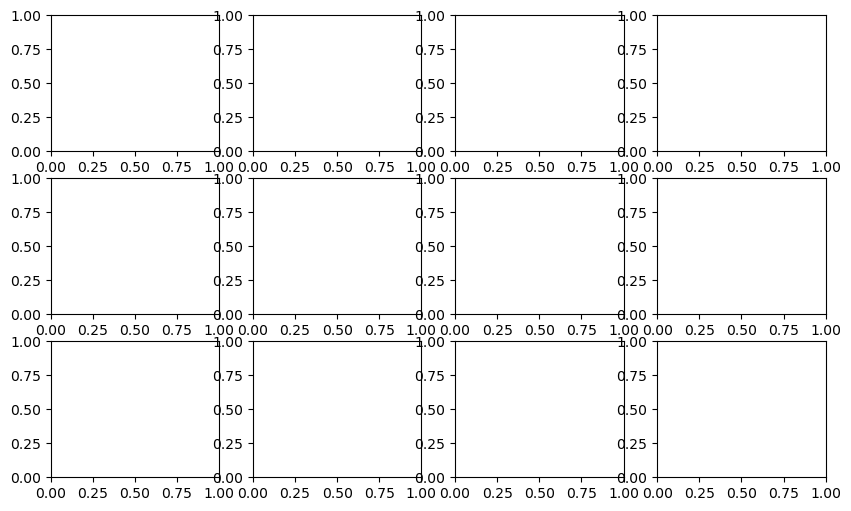

In [ ]:
D, kp_coords = extract_descriptors_8x8(im_gray=im_small, coords=coords_anms, win_size=40, desc_size=8, blur_sigma=1.0)

In [ ]:
def match_descriptors(D1, D2, ratio_thresh=0.7, mutual=True):
    #get the pariware dist
    dist = pairwise_sq_dists(D1, D2)
    #for each discripter sort the distance to D2 in ascending order bc we need indices
    order = np.argsort(dist, axis=1)

    #we need nearest (best second)
    best   = order[:,0]
    second = order[:,1]

    #get hte actual distance vals
    d_best   = dist[np.arange(dist.shape[0]), best]
    d_second = dist[np.arange(dist.shape[0]), second]
    
    ratio = d_best / (d_second + 1e-12)

    keep = ratio < ratio_thresh
    # absolute distance gate
    med = np.median(d_best[keep]) if np.any(keep) else np.median(d_best)
    keep &= d_best < med * 1.5

    i1 = np.nonzero(keep)[0]
    i2 = best[keep]

    if not mutual or len(i1) == 0:
        return i1, i2, ratio[keep]

    best_back = np.argmin(dist, axis=0)  # N
    mutual_mask = best_back[i2] == i1
    return i1[mutual_mask], i2[mutual_mask], ratio[keep][mutual_mask]

candidates for RANSAC: 47


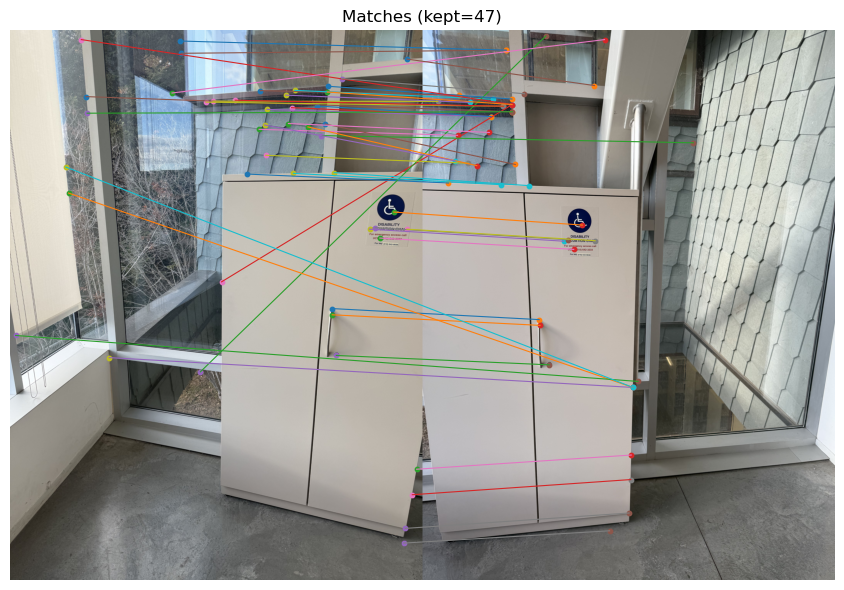

In [ ]:
imA_path = "./media/set3a.jpg"
imB_path = "./media/set3b.jpg"
scale = 0.4

rgb1 = imread(imA_path)
rgb2 = imread(imB_path)
g1 = rgb2gray(rgb1).astype(np.float32)
g2 = rgb2gray(rgb2).astype(np.float32)

im_small_1  = rescale(g1, scale, anti_aliasing=True)
im_small_2  = rescale(g2, scale, anti_aliasing=True)
rgb_small_1 = rescale(rgb1, scale, anti_aliasing=True, channel_axis=-1)
rgb_small_2 = rescale(rgb2, scale, anti_aliasing=True, channel_axis=-1)

h1, c1 = get_harris_corners(im_small_1, edge_discard=20)
h2, c2 = get_harris_corners(im_small_2, edge_discard=20)

kp1 = anms(c1, h1, N=600, c_robust=0.9)
kp2 = anms(c2, h2, N=600, c_robust=0.9)

D1, kp1 = extract_descriptors_8x8(im_small_1, kp1, win_size=40, desc_size=8, blur_sigma=1.0)
D2, kp2 = extract_descriptors_8x8(im_small_2, kp2, win_size=40, desc_size=8, blur_sigma=1.0)

#L2-normalize
D1n = D1 / (np.linalg.norm(D1, axis=1, keepdims=True) + 1e-6)
D2n = D2 / (np.linalg.norm(D2, axis=1, keepdims=True) + 1e-6)


i1, i2, ratio = match_descriptors(D1n, D2n, ratio_thresh=0.70, mutual=False)
K = min(350, len(i1))
keep = np.argsort(ratio)[:K]
i1, i2, ratio = i1[keep], i2[keep], ratio[keep]



In [75]:
#define a func to get polygon are 
    #in testbook get the shoelace formula
def quad_area(pts):
    # pts: (4,2) in (x,y)
    x, y = pts[:,0], pts[:,1]
    return 0.5 * abs(np.sum(x*np.roll(y,-1) - y*np.roll(x,-1)))

#error metric
def symmetric_transfer_error(H, pts1_xy, pts2_xy):
    N = pts1_xy.shape[0]
    #get homo coords
    p1 = np.c_[pts1_xy, np.ones(N)]
    p2 = np.c_[pts2_xy, np.ones(N)]

    ##transofmr al poitns from im1 to im2
    Hp1 = (H @ p1.T).T
    Hp1 = Hp1[:, :2] / Hp1[:, 2:3]

    #get inv (for cartesian ponit) and get inv homo
    Hinv = np.linalg.inv(H)
    Hinvp2 = (Hinv @ p2.T).T
    Hinvp2 = Hinvp2[:, :2] / Hinvp2[:, 2:3]

    return np.linalg.norm(Hp1 - pts2_xy, axis=1) + np.linalg.norm(Hinvp2 - pts1_xy, axis=1)

def ransac_homography(kp1_yx, kp2_yx, i1, i2, iters=5000, thresh=4.0, min_inliers=10, area_min=8.0):
    #convert the kaeypoint array to x,y cuz thats what homo uses 
    pts1_xy = kp1_yx[:, i1].T[:, [1,0]].astype(float)
    pts2_xy = kp2_yx[:, i2].T[:, [1,0]].astype(float)

    best_inliers, best_H, best_count = None, None, -1
    N = pts1_xy.shape[0]

    #in the ransac loop
    #randomsly sample coorepsondsance
    #extra points
    #skip samples too small
    for _ in range(iters):
        idx = rng.choice(N, size=4, replace=False)
        p1 = pts1_xy[idx]
        p2 = pts2_xy[idx]

        #too small
        if quad_area(p1) < area_min or quad_area(p2) < area_min:
            continue
        
        #keep inliers based on errs threshold
        errs = symmetric_transfer_error(Hcand, pts1_xy, pts2_xy)
        inliers = errs < thresh
        count = int(inliers.sum())

        #update besrt_coun
        if count > best_count:
            best_count = count
            best_inliers = inliers
            best_H = Hcand
            
    H_refit = computeH(pts1_xy[best_inliers], pts2_xy[best_inliers])
    return H_refit, best_inliers


In [ ]:
H_auto, inliers = ransac_homography(kp1, kp2, i1, i2, iters=2000, thresh=2.5)

im1_small_u8 = (rgb_small_1 * 255).astype(np.uint8)
im2_small_u8 = (rgb_small_2 * 255).astype(np.uint8)

out_shape, T = mosaic_bounds(im1_small_u8, im2_small_u8, H_auto)
H_total = T @ H_auto

im1_warped = warpImageBilinear(im1_small_u8, H_total, out_shape)

#generate hte mosaic ehere after we blinear func
mosaic = np.zeros_like(im1_warped)
h2, w2 = im2_small_u8.shape[:2]
tx, ty = T[0,2], T[1,2]
#loop over b shiting mosaic by (tx,ty) i think (ASK ON eD)
for i in range(h2):
    for j in range(w2):
        x = int(j + tx); y = int(i + ty)
        if 0 <= y < mosaic.shape[0] and 0 <= x < mosaic.shape[1]:
            mosaic[y, x] = im2_small_u8[i, j]


valid1 = (im1_warped.sum(axis=2) > 0)
valid2 = (mosaic.sum(axis=2) > 0)
a1 = alpha_from_valid(valid1)
a2 = alpha_from_valid(valid2) * 1.3

W = (a1 + a2 + 1e-6)[..., None]
mosaic_blend = (im1_warped * a1[...,None] + mosaic * a2[...,None]) / W
mosaic_blend = np.clip(mosaic_blend, 0, 255).astype(np.uint8)

/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_56944/515822756.py:15: RuntimeWarning: divide by zero encountered in divide
  Hp1 = Hp1[:, :2] / Hp1[:, 2:3]
/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_56944/515822756.py:15: RuntimeWarning: invalid value encountered in divide
  Hp1 = Hp1[:, :2] / Hp1[:, 2:3]
/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_56944/515822756.py:19: RuntimeWarning: divide by zero encountered in divide
  Hinvp2 = Hinvp2[:, :2] / Hinvp2[:, 2:3]
/var/folders/1j/2tm4cv2s2vndcm34yjt_7t640000gn/T/ipykernel_56944/515822756.py:19: RuntimeWarning: invalid value encountered in divide
  Hinvp2 = Hinvp2[:, :2] / Hinvp2[:, 2:3]


RuntimeError: RANSAC failed to find a good homography